In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import imageio

from google.colab import drive

In [ ]:
drive.mount('/content/drive')
vidpath = '/content/drive/MyDrive/HomographyProject/CookbookTestVideo.mp4'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# prompt: load a single frame of a video file

def load_single_frame(video_path, frame_number):
  """Loads a single frame from a video file.

  Args:
    video_path: Path to the video file.
    frame_number: The frame number to load (0-indexed).

  Returns:
    A NumPy array representing the frame, or None if the frame
    number is invalid or the file cannot be opened.
  """
  try:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
      print(f"Error opening video file: {video_path}")
      return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if not 0 <= frame_number < total_frames:
      print(f"Invalid frame number: {frame_number}. Total frames: {total_frames}")
      return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()

    if ret:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    else:
        print(f"Error reading frame {frame_number}")
        return None
  except Exception as e:
    print(f"An error occurred: {e}")
    return None


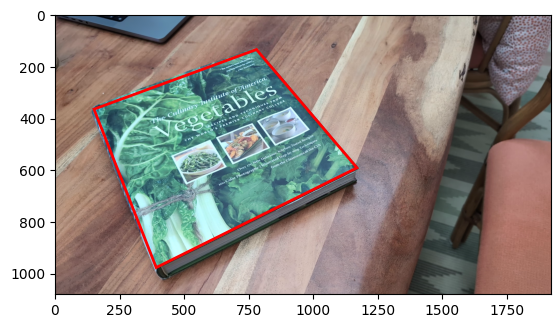

In [ ]:
# get corner points from user
frame0 = load_single_frame(vidpath, 0)
# format: Row/Col, [TL, TR, BR, BL]
corners = np.array([[363, 151], [132, 780], [590, 1169], [976, 392]])

# calculate output size by squaring input points
width = np.max(np.abs([corners[1,0]-corners[0,0], corners[2,0]-corners[3,0]]))
height = np.max(np.abs([corners[3,1]-corners[0,0], corners[2,1]-corners[1,1]]))
rectcorners = np.array([[0,0], [0, width], [height, width], [height, 0]])

# show the selected region
plt.imshow(frame0)
plt.fill(corners[:,1], corners[:,0], edgecolor='red', lw=2, facecolor='none')
plt.show()

In [ ]:
# Rectify Original Image
def rectify(img, incorners, outcorners):
  outsize = (outcorners[2, 1], outcorners[2, 0])
  H, m = cv2.findHomography(incorners[:,::-1], outcorners[:,::-1], cv2.RANSAC) # uses col,row order
  outimg = cv2.warpPerspective(img, H, outsize)
  return outimg

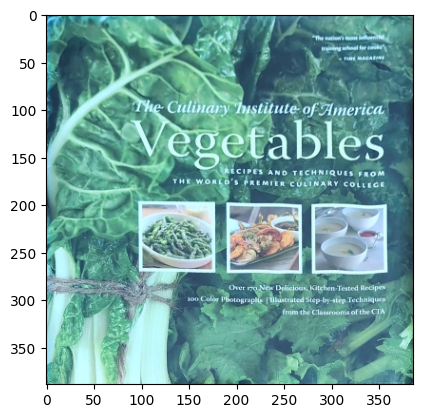

In [ ]:
# show original rectified image
refimg = rectify(frame0, corners, rectcorners)
plt.imshow(refimg)
plt.show()

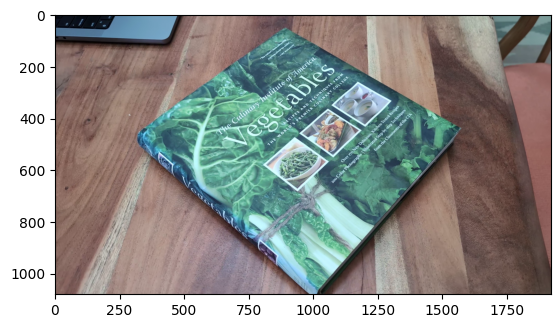

In [ ]:
# load another frame
frame1 = load_single_frame(vidpath, 200)
plt.imshow(frame1)
plt.show()

In [ ]:
def find_homography(img0, img1):
  gray0 = cv2.cvtColor(img0, cv2.COLOR_RGB2GRAY)
  gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)

  orb = cv2.ORB_create()
  bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

  kp0, des0 = orb.detectAndCompute(gray0, None)
  kp1, des1 = orb.detectAndCompute(gray1, None)

  matches = bf.match(des0, des1)
  matches = sorted(matches, key = lambda x:x.distance)

  src_pts = np.float32([kp0[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
  des_pts = np.float32([kp1[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

  H, m = cv2.findHomography(src_pts, des_pts, cv2.RANSAC, 5.0)

  return H

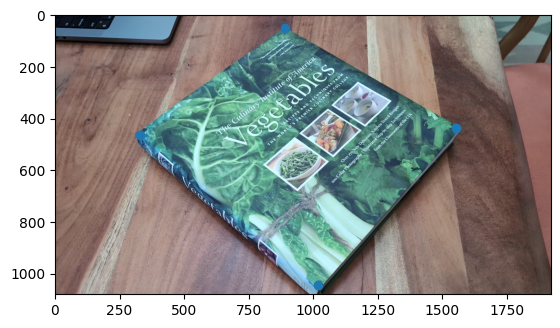

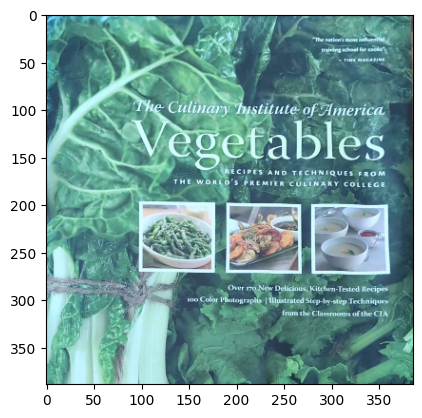

In [ ]:
# warp new frame to rectified space
H = find_homography(refimg, frame1)

# change to both xy and column format
newcorners = cv2.perspectiveTransform(np.float32(rectcorners[:, ::-1].reshape(-1, 1, 2)), H)

# show new corners
plt.imshow(frame1)
plt.scatter(newcorners[:,:,0], newcorners[:,:,1])
plt.show()

# show rectified image
rectimg = rectify(frame1, newcorners, rectcorners)
plt.imshow(rectimg)
plt.show()

.
.
.
.
.
.
.
.


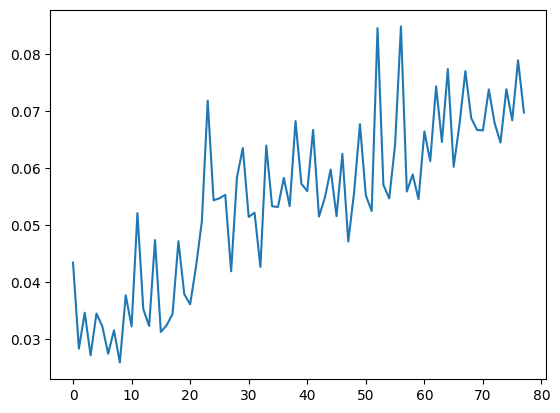

In [ ]:
# plot total absolute pixel difference for each frame of the video
incr = 3
frame_ixs = range(0,233,incr)
nframes = len(frame_ixs)

error = np.zeros(nframes)
imgs = np.zeros([nframes, height, width, 3])
for i, fi in enumerate(frame_ixs):
  if i % 10 == 0:
    print('.')
  fimg = load_single_frame(vidpath, fi)
  H = find_homography(refimg, fimg)
  newcorners = cv2.perspectiveTransform(np.float32(rectcorners[:, ::-1].reshape(-1, 1, 2)), H)
  rectimg = rectify(fimg, newcorners, rectcorners)

  error[i] = np.mean(np.abs(np.float64(refimg)/255.-np.float64(rectimg)/255.))
  imgs[i] = rectimg

plt.plot(error)
plt.show()

In [ ]:
with imageio.get_writer("vegetables_inc3.gif", mode="I") as writer:
  for idx, frame in enumerate(imgs):
    print("Adding frame to GIF file: ", idx + 1)
    writer.append_data(np.uint8(frame))

Adding frame to GIF file:  1
Adding frame to GIF file:  2
Adding frame to GIF file:  3
Adding frame to GIF file:  4
Adding frame to GIF file:  5
Adding frame to GIF file:  6
Adding frame to GIF file:  7
Adding frame to GIF file:  8
Adding frame to GIF file:  9
Adding frame to GIF file:  10
Adding frame to GIF file:  11
Adding frame to GIF file:  12
Adding frame to GIF file:  13
Adding frame to GIF file:  14
Adding frame to GIF file:  15
Adding frame to GIF file:  16
Adding frame to GIF file:  17
Adding frame to GIF file:  18
Adding frame to GIF file:  19
Adding frame to GIF file:  20
Adding frame to GIF file:  21
Adding frame to GIF file:  22
Adding frame to GIF file:  23
Adding frame to GIF file:  24
Adding frame to GIF file:  25
Adding frame to GIF file:  26
Adding frame to GIF file:  27
Adding frame to GIF file:  28
Adding frame to GIF file:  29
Adding frame to GIF file:  30
Adding frame to GIF file:  31
Adding frame to GIF file:  32
Adding frame to GIF file:  33
Adding frame to GIF